## Perhitungan Jarak Dynamic Time Warping antara 100 Audio Lama (Buka/Tutup) dan 1 Audio Baru

### Tahap 1 Import Library

In [20]:
import os
import numpy as np
import librosa
import librosa.display
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import pandas as pd



### Tahap 2 Pengecekan Dataset Audio

In [22]:
import os

# Folder dataset
folder_buka = "AudioDTW/AudioLama/"
folder_new = "AudioDTW/AudioBaru/"

# --- Fungsi untuk mendapatkan file .wav ---
def get_wav_files(folder):
    if not os.path.exists(folder):
        print(f" Folder tidak ditemukan: {folder}")
        return []
    
    files = [f for f in os.listdir(folder) if f.lower().endswith(".wav")]
    return sorted(files)


# --- Ambil file dari tiap folder ---
buka_files = get_wav_files(folder_buka)
new_files = get_wav_files(folder_new)

# --- TAMPILKAN INFO DATASET ---
print("=== DATASET CHECK ===")
print(f"Jumlah audio 'buka'  : {len(buka_files)} file")
print(f"Jumlah audio 'baru'  : {len(new_files)} file")

# Tampilkan maksimal 10 contoh file baru
print("\nContoh file 'buka' :", buka_files[:5])
print("Contoh file 'baru' :", new_files[:5])

# --- Validasi dataset ---
if len(buka_files) == 0:
    print("\n Error: Tidak ada audio di folder AudioLama/")
elif len(new_files) == 0:
    print("\n Error: Tidak ada audio di folder AudioBaru/")
else:
    print("\n Dataset siap diproses! Semua file dalam format .wav")


=== DATASET CHECK ===
Jumlah audio 'buka'  : 100 file
Jumlah audio 'baru'  : 1 file

Contoh file 'buka' : ['buka 1.wav', 'buka 57.wav', 'buka10.wav', 'buka100.wav', 'buka11.wav']
Contoh file 'baru' : ['baru1.wav']

 Dataset siap diproses! Semua file dalam format .wav


### Tahap 3 Load Audio dan Normalisasi Sample Rate ke 16 kHz

In [23]:
import librosa
import os

folder_lama = "AudioDTW/AudioLama/"
folder_baru = "AudioDTW/AudioBaru/"

def load_all_audio(folder, target_sr=16000):
    data = {}
    sr_list = []  # untuk menyimpan sample rate asli

    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".wav"):
            path = os.path.join(folder, f)

            # Ambil sample rate asli
            try:
                sr_original = librosa.get_samplerate(path)
            except:
                sr_original = None

            sr_list.append(sr_original)

            # Load + paksa samakan sr
            y, _ = librosa.load(path, sr=target_sr)
            data[f] = y

    return data, sr_list


# === LOAD DATASET ===
audio_lama, sr_lama = load_all_audio(folder_lama)
audio_baru, sr_baru = load_all_audio(folder_baru)

print("Jumlah audio lama :", len(audio_lama))
print("Jumlah audio baru :", len(audio_baru))

# === CEK APAKAH SAMPLE RATE SAMA? ===
def check_sr(sr_list, jenis):
    unik = set(sr_list)
    print(f"\nSample rate asli {jenis} :", unik)

    if None in unik:
        print(" Ada file yang gagal dibaca sample ratenya!")

    if len(unik) == 1:
        print(f" Semua sample rate {jenis} konsisten!")
    else:
        print(f" Sample rate {jenis} TIDAK sama! Harus disamakan.")


check_sr(sr_lama, "audio lama")
check_sr(sr_baru, "audio baru")


Jumlah audio lama : 100
Jumlah audio baru : 1

Sample rate asli audio lama : {48000}
 Semua sample rate audio lama konsisten!

Sample rate asli audio baru : {48000}
 Semua sample rate audio baru konsisten!


### Tahap 4 Prepocessing

In [24]:
import os
import librosa

# Folder dataset
folder_lama = "AudioDTW/AudioLama/"
folder_baru = "AudioDTW/AudioBaru/"

# Target sample rate
TARGET_SR = 16000

# Fungsi untuk load dan preprocess audio
def load_and_preprocess(folder, target_sr=TARGET_SR):
    """
    Load semua file .wav dari folder, convert ke mono, normalize amplitude.
    Mengembalikan dictionary {filename: audio_array} dan list sample rate asli.
    """
    data = {}
    sr_list = []

    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".wav"):
            path = os.path.join(folder, f)

            # Ambil sample rate asli
            try:
                sr_orig = librosa.get_samplerate(path)
            except:
                sr_orig = None
            sr_list.append(sr_orig)

            # Load audio, convert stereo → mono otomatis, resample ke target_sr
            y, _ = librosa.load(path, sr=target_sr)

            # --- Preprocessing ringan ---
            # Normalize amplitude supaya volume konsisten
            y = librosa.util.normalize(y)

            # Simpan hasil
            data[f] = y

    return data, sr_list

# === Load dan preprocess semua audio lama dan baru ===
audio_lama, sr_lama = load_and_preprocess(folder_lama)
audio_baru, sr_baru = load_and_preprocess(folder_baru)

# === Info dataset setelah preprocessing ===
print(" Preprocessing selesai")
print(f"Jumlah audio lama : {len(audio_lama)}")
print(f"Jumlah audio baru : {len(audio_baru)}")


 Preprocessing selesai
Jumlah audio lama : 100
Jumlah audio baru : 1


### Tahap 5 Visualisasi 

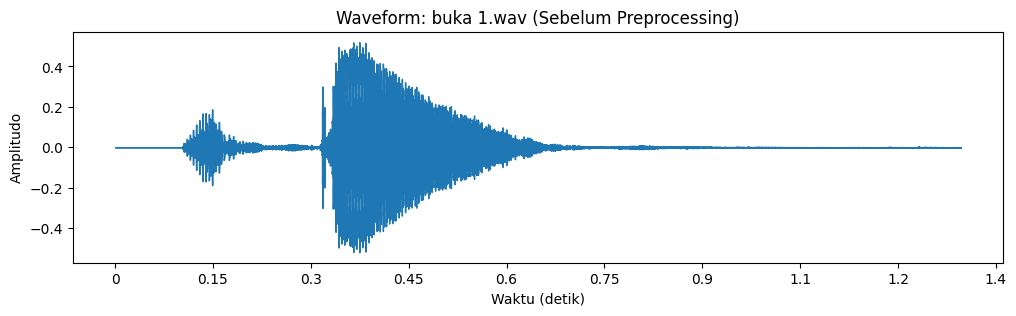

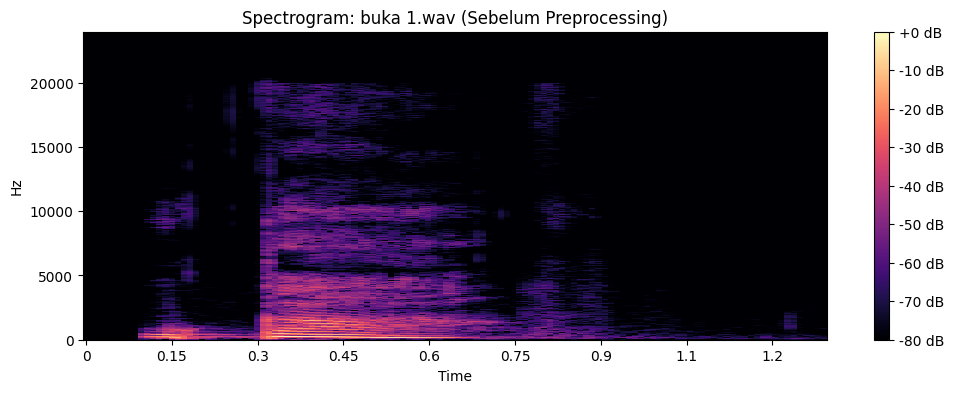

Durasi: 1.296 detik
Min amplitude: -0.49389648 Max amplitude: 0.51989746


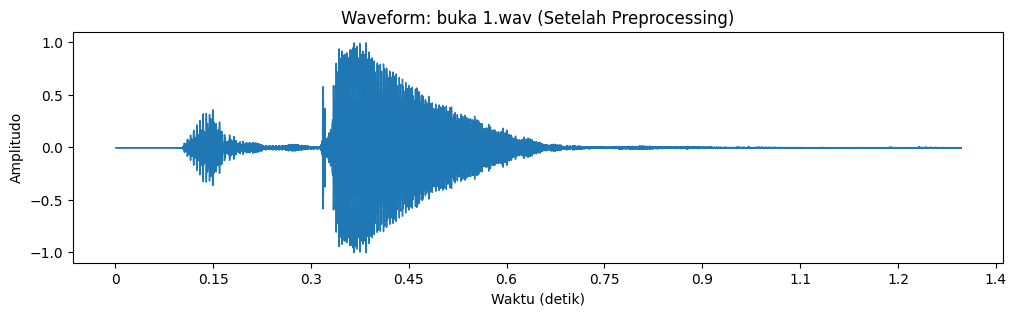

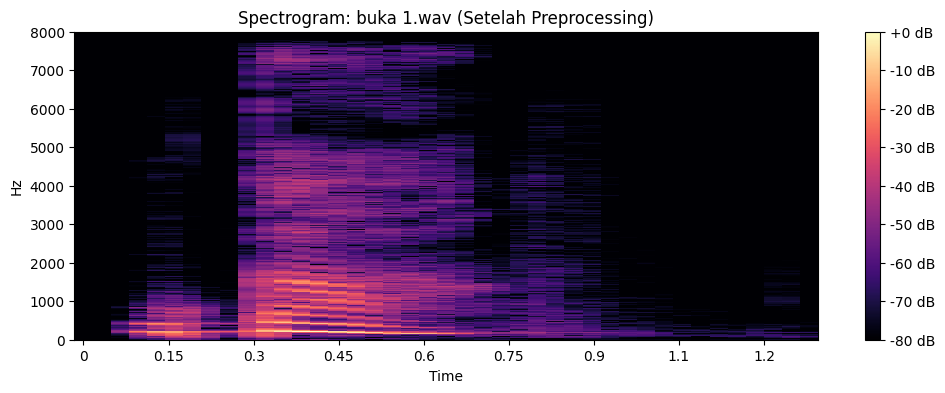

Durasi: 1.296 detik
Min amplitude: -0.9513202 Max amplitude: 1.0


In [25]:

# Folder dataset
folder_lama = "AudioDTW/AudioLama/"
TARGET_SR = 16000

# --- Load raw audio (sebelum preprocessing) ---
def load_raw_audio(folder):
    data = {}
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".wav"):
            path = os.path.join(folder, f)
            y, sr = librosa.load(path, sr=None)  # sr=None biar tetap asli
            data[f] = (y, sr)
    return data

raw_audio_lama = load_raw_audio(folder_lama)

# --- Load & preprocessing audio ---
def load_and_preprocess(folder, target_sr=TARGET_SR):
    data = {}
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".wav"):
            path = os.path.join(folder, f)
            y, _ = librosa.load(path, sr=target_sr)  # convert mono + resample
            y = librosa.util.normalize(y)             # normalize amplitude
            data[f] = y
    return data

audio_lama = load_and_preprocess(folder_lama)

# --- Pilih file pertama ---
first_file = list(audio_lama.keys())[0]

# --- Fungsi untuk menampilkan waveform dan spectrogram ---
def plot_audio(y, sr, title="Audio"):
    plt.figure(figsize=(12,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform: {title}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")
    plt.show()

    # Spectrogram
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    plt.figure(figsize=(12,4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Spectrogram: {title}")
    plt.show()

    # Info
    print("Durasi:", len(y)/sr, "detik")
    print("Min amplitude:", y.min(), "Max amplitude:", y.max())

# --- Plot raw audio ---
y_raw, sr_raw = raw_audio_lama[first_file]
plot_audio(y_raw, sr_raw, title=f"{first_file} (Sebelum Preprocessing)")

# --- Plot preprocessed audio ---
y_proc = audio_lama[first_file]
plot_audio(y_proc, TARGET_SR, title=f"{first_file} (Setelah Preprocessing)")


### Tahap 6 Perhitungan Kemiripan Audio Menggunakan MFCC dan FastDTW

In [28]:
import os
import librosa
import numpy as np
import pandas as pd
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# --- Folder & parameter ---
folder_lama = "AudioDTW/AudioLama/"
folder_baru = "AudioDTW/AudioBaru/"
TARGET_SR = 16000

n_mfcc = 13
hop_length = 512
n_fft = 2048

# --- Load & Preprocessing ---
def load_and_preprocess(folder, target_sr=TARGET_SR):
    data = {}
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".wav"):
            path = os.path.join(folder, f)
            y, _ = librosa.load(path, sr=target_sr)
            y = librosa.util.normalize(y)
            data[f] = y
    return data

audio_lama = load_and_preprocess(folder_lama)
audio_baru = load_and_preprocess(folder_baru)

# --- Ekstraksi MFCC ---
def extract_mfcc(audio_dict, sr=TARGET_SR, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft):
    mfcc_dict = {}
    for filename, y in audio_dict.items():
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=n_mfcc,
            hop_length=hop_length, n_fft=n_fft
        )
        mfcc_dict[filename] = mfcc
    return mfcc_dict

mfcc_lama = extract_mfcc(audio_lama)
mfcc_baru = extract_mfcc(audio_baru)

# --- CEK UKURAN MFCC 13×T ---
print("\n=== Ukuran MFCC Audio Lama (13 × T) ===")
for f in mfcc_lama:
    print(f"{f}: {mfcc_lama[f].shape}")

print("\n=== Ukuran MFCC Audio Baru (13 × T) ===")
for f in mfcc_baru:
    print(f"{f}: {mfcc_baru[f].shape}")

# --- Hitung FastDTW untuk semua pasangan ---
files_lama = list(mfcc_lama.keys())
files_baru = list(mfcc_baru.keys())

distance_matrix = np.zeros((len(files_lama), len(files_baru)))

for i, f_lama in enumerate(files_lama):
    X = mfcc_lama[f_lama].T
    for j, f_baru in enumerate(files_baru):
        Y = mfcc_baru[f_baru].T
        distance, _ = fastdtw(X, Y, dist=euclidean)
        distance_matrix[i, j] = distance

# --- Tampilkan dalam bentuk DataFrame ---
df = pd.DataFrame(distance_matrix, index=files_lama, columns=files_baru)

print("\n=== FastDTW Distance Table (Rapi) ===\n")
print(df.to_string())



=== Ukuran MFCC Audio Lama (13 × T) ===
buka 1.wav: (13, 41)
buka 57.wav: (13, 34)
buka10.wav: (13, 63)
buka100.wav: (13, 43)
buka11.wav: (13, 74)
buka12.wav: (13, 70)
buka13.wav: (13, 61)
buka14.wav: (13, 67)
buka15.wav: (13, 56)
buka16.wav: (13, 60)
buka17.wav: (13, 67)
buka18.wav: (13, 63)
buka19.wav: (13, 52)
buka2.wav: (13, 65)
buka20.wav: (13, 55)
buka21.wav: (13, 58)
buka22.wav: (13, 55)
buka23.wav: (13, 52)
buka24.wav: (13, 64)
buka25.wav: (13, 55)
buka26.wav: (13, 49)
buka27.wav: (13, 54)
buka28.wav: (13, 52)
buka29.wav: (13, 60)
buka3.wav: (13, 75)
buka30.wav: (13, 49)
buka31.wav: (13, 59)
buka32.wav: (13, 54)
buka33.wav: (13, 55)
buka34.wav: (13, 39)
buka35.wav: (13, 50)
buka36.wav: (13, 52)
buka37.wav: (13, 56)
buka38.wav: (13, 45)
buka39.wav: (13, 43)
buka4.wav: (13, 74)
buka40.wav: (13, 49)
buka41.wav: (13, 48)
buka42.wav: (13, 50)
buka43.wav: (13, 45)
buka44.wav: (13, 44)
buka45.wav: (13, 37)
buka46.wav: (13, 41)
buka47.wav: (13, 45)
buka48.wav: (13, 52)
buka49.wav: (13

### Tahap 7 Ambil 5 Audio Lama Paling Mirip dengan Satu Audio Baru

In [33]:
target_audio_baru = "baru1.wav"   # ubah sesuai file target
top_n = 5

print(f"\n=== 5 Audio Lama Paling Mirip dengan {target_audio_baru} ===")

# Sort berdasarkan jarak terkecil
top_matches = df[target_audio_baru].sort_values().head(top_n)

print(top_matches.to_string())



=== 5 Audio Lama Paling Mirip dengan baru1.wav ===
buka12.wav    3577.330609
buka9.wav     3593.319786
buka2.wav     3664.468699
buka21.wav    3666.936965
buka22.wav    3722.374522


### Tahap 8 Heatmap Visualisasi

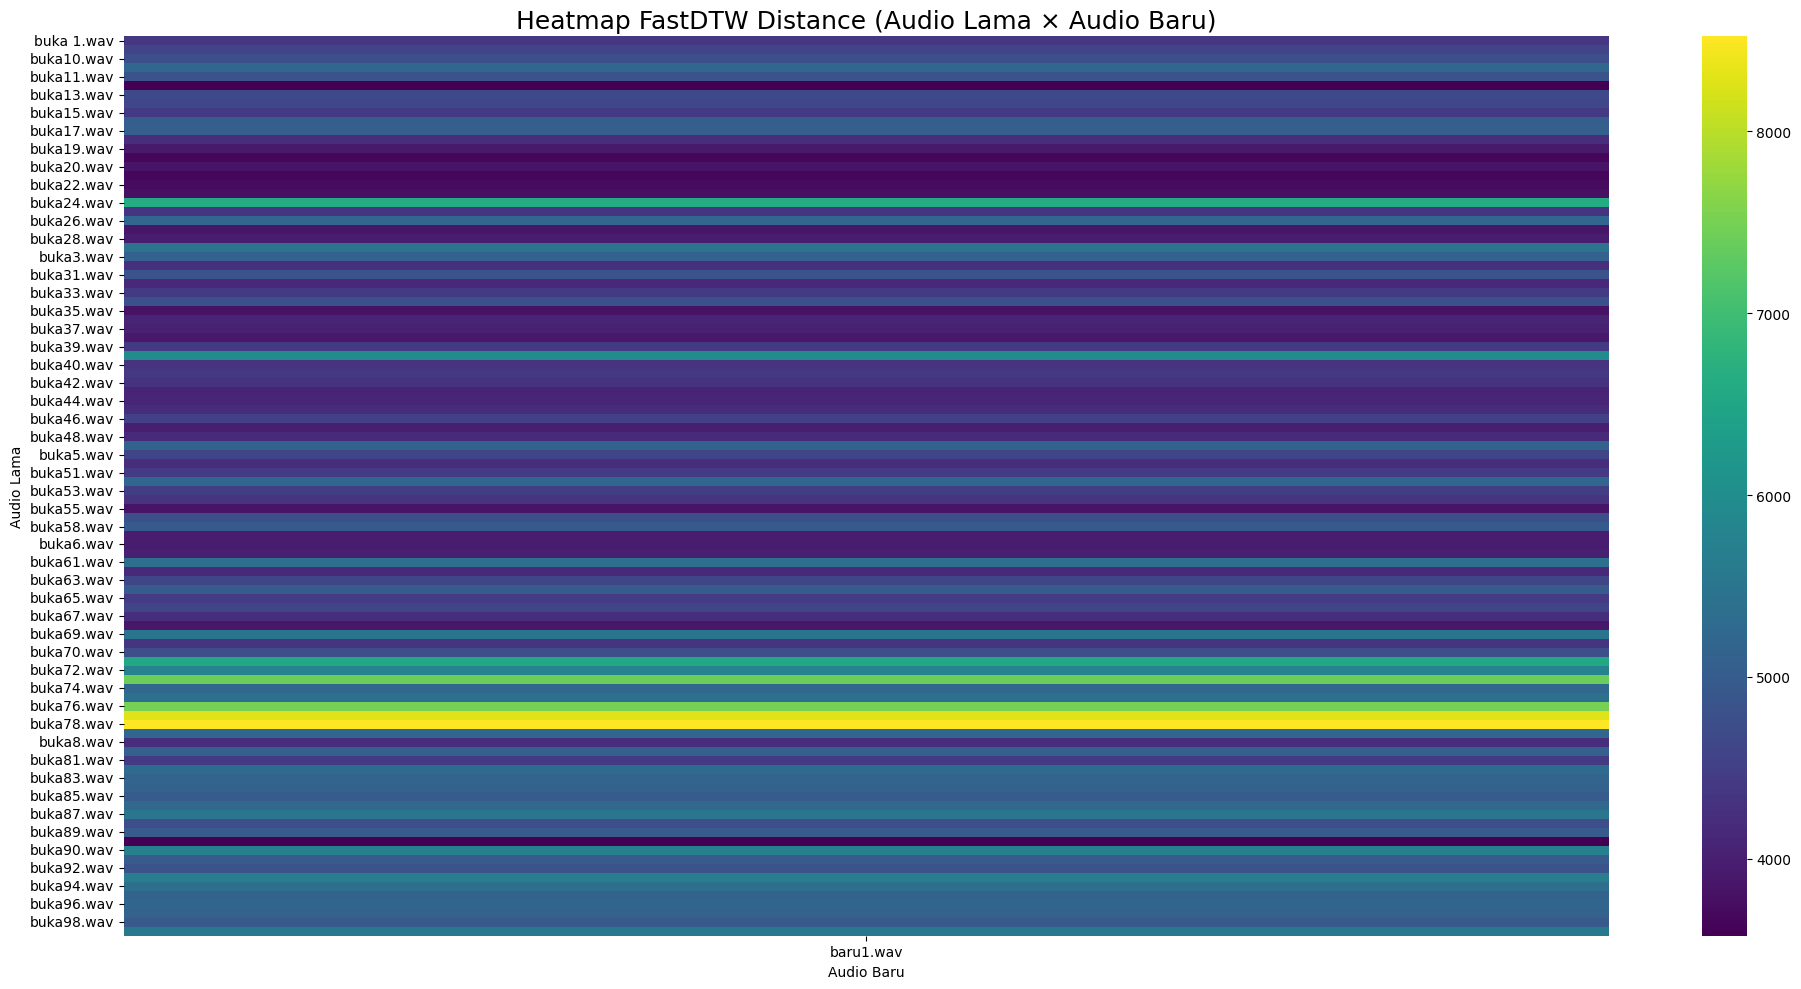

In [37]:
# ============================
#   TAHAP 8 — Heatmap Visualisasi
# ============================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.heatmap(df, cmap="viridis")
plt.title("Heatmap FastDTW Distance (Audio Lama × Audio Baru)", fontsize=18)
plt.xlabel("Audio Baru")
plt.ylabel("Audio Lama")
plt.tight_layout()
plt.show()


In [38]:
print("\n=== Debug Jumlah Audio ===")
print("File lama terbaca :", len(audio_lama))
print("File baru terbaca :", len(audio_baru))

print("\nDaftar file lama:")
for f in audio_lama.keys():
    print(f)



=== Debug Jumlah Audio ===
File lama terbaca : 100
File baru terbaca : 1

Daftar file lama:
buka 1.wav
buka 57.wav
buka10.wav
buka100.wav
buka11.wav
buka12.wav
buka13.wav
buka14.wav
buka15.wav
buka16.wav
buka17.wav
buka18.wav
buka19.wav
buka2.wav
buka20.wav
buka21.wav
buka22.wav
buka23.wav
buka24.wav
buka25.wav
buka26.wav
buka27.wav
buka28.wav
buka29.wav
buka3.wav
buka30.wav
buka31.wav
buka32.wav
buka33.wav
buka34.wav
buka35.wav
buka36.wav
buka37.wav
buka38.wav
buka39.wav
buka4.wav
buka40.wav
buka41.wav
buka42.wav
buka43.wav
buka44.wav
buka45.wav
buka46.wav
buka47.wav
buka48.wav
buka49.wav
buka5.wav
buka50.wav
buka51.wav
buka52.wav
buka53.wav
buka54.wav
buka55.wav
buka56.wav
buka58.wav
buka59.wav
buka6.wav
buka60.wav
buka61.wav
buka62.wav
buka63.wav
buka64.wav
buka65.wav
buka66.wav
buka67.wav
buka68.wav
buka69.wav
buka7.wav
buka70.wav
buka71.wav
buka72.wav
buka73.wav
buka74.wav
buka75.wav
buka76.wav
buka77.wav
buka78.wav
buka79.wav
buka8.wav
buka80.wav
buka81.wav
buka82.wav
buka83.wav